# Patient Admissions and Outcomes Analysis
## MIMIC-IV Clinical Database Demo

### Overview
This analysis explores patient admissions data from Beth Israel Deaconess Medical Center 
using the MIMIC-IV Demo dataset. The goal is to identify patterns in admissions, 
length of stay, and mortality to support clinical operations and resource planning decisions.

### Dataset
**Source:** MIMIC-IV Clinical Database Demo v2.2 (PhysioNet)
**Tables used:** patients, admissions
**Total admissions analysed:** 275
**Patient population:** 100 de-identified hospital patients

### Clinical Questions
1. What are the most common admission types?
2. Which admission types have the longest average length of stay?
3. What is the in-hospital mortality rate?
4. What is the age distribution of admitted patients?
5. Does age predict length of stay?

In [1]:
# Import the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load patients table and preview
patients = pd.read_csv("../data/raw/mimic-iv-clinical-database-demo-2.2/hosp/patients.csv.gz")
print(patients.shape)
patients.head()

(100, 6)


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10014729,F,21,2125,2011 - 2013,NaN
1,10003400,F,72,2134,2011 - 2013,2137-09-02
2,10002428,F,80,2155,2011 - 2013,NaN
3,10032725,F,38,2143,2011 - 2013,2143-03-30
4,10027445,F,48,2142,2011 - 2013,2146-02-09


In [3]:
# Check data types for patients table
print(patients.dtypes)

subject_id            int64
gender               object
anchor_age            int64
anchor_year           int64
anchor_year_group    object
dod                  object
dtype: object


In [4]:
# Check the missing values for the patients table
print(patients.isnull().sum())

subject_id            0
gender                0
anchor_age            0
anchor_year           0
anchor_year_group     0
dod                  69
dtype: int64


In [3]:
# Load admissions table and preview
admissions = pd.read_csv("../data/raw/mimic-iv-clinical-database-demo-2.2/hosp/admissions.csv.gz")
print(admissions.shape)
admissions.head()

(275, 16)


,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10004235,24181354,2196-02-24 14:38:00,2196-03-04 14:02:00,NaN,URGENT,P03YMR,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicaid,ENGLISH,SINGLE,BLACK/CAPE VERDEAN,2196-02-24 12:15:00,2196-02-24 17:07:00,0
1,10009628,25926192,2153-09-17 17:08:00,2153-09-25 13:20:00,NaN,URGENT,P41R5N,TRANSFER FROM HOSPITAL,HOME HEALTH CARE,Medicaid,?,MARRIED,HISPANIC/LATINO - PUERTO RICAN,NaN,NaN,0
2,10018081,23983182,2134-08-18 02:02:00,2134-08-23 19:35:00,NaN,URGENT,P233F6,TRANSFER FROM HOSPITAL,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,WHITE,2134-08-17 16:24:00,2134-08-18 03:15:00,0
3,10006053,22942076,2111-11-13 23:39:00,2111-11-15 17:20:00,2111-11-15 17:20:00,URGENT,P38TI6,TRANSFER FROM HOSPITAL,DIED,Medicaid,ENGLISH,NaN,UNKNOWN,NaN,NaN,1
4,10031404,21606243,2113-08-04 18:46:00,2113-08-06 20:57:00,NaN,URGENT,P07HDB,TRANSFER FROM HOSPITAL,HOME,Other,ENGLISH,WIDOWED,WHITE,NaN,NaN,0


In [7]:
# Check data types for admissions table
print(admissions.dtypes)

subject_id               int64
hadm_id                  int64
admittime               object
dischtime               object
deathtime               object
admission_type          object
admit_provider_id       object
admission_location      object
discharge_location      object
insurance               object
language                object
marital_status          object
race                    object
edregtime               object
edouttime               object
hospital_expire_flag     int64
dtype: object


In [8]:
# Check the missing values for the  admissions table
print(admissions.isnull().sum())

subject_id                0
hadm_id                   0
admittime                 0
dischtime                 0
deathtime               260
admission_type            0
admit_provider_id         0
admission_location        0
discharge_location       42
insurance                 0
language                  0
marital_status           12
race                      0
edregtime                93
edouttime                93
hospital_expire_flag      0
dtype: int64


In [4]:
# Convert date columns to datetime format
admissions['admittime'] = pd.to_datetime(admissions['admittime'])
admissions['dischtime'] = pd.to_datetime(admissions['dischtime'])
admissions['deathtime'] = pd.to_datetime(admissions['deathtime'])
admissions['edregtime'] = pd.to_datetime(admissions['edregtime'])
admissions['edouttime'] = pd.to_datetime(admissions['edouttime'])

print(admissions.dtypes)

subject_id                       int64
hadm_id                          int64
admittime               datetime64[ns]
dischtime               datetime64[ns]
deathtime               datetime64[ns]
admission_type                  object
admit_provider_id               object
admission_location              object
discharge_location              object
insurance                       object
language                        object
marital_status                  object
race                            object
edregtime               datetime64[ns]
edouttime               datetime64[ns]
hospital_expire_flag             int64
dtype: object


In [5]:
# Convert dod to datetime in the patients table
patients['dod'] = pd.to_datetime(patients['dod'])

print(patients.dtypes)

subject_id                    int64
gender                       object
anchor_age                    int64
anchor_year                   int64
anchor_year_group            object
dod                  datetime64[ns]
dtype: object


In [6]:
# Merge patients and admissions on subject_id
merged = pd.merge(patients, admissions, on = 'subject_id', how ='inner')

print(merged.shape)
merged.head()

(275, 21)


,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod,hadm_id,admittime,dischtime,deathtime,...,admit_provider_id,admission_location,discharge_location,insurance,language,marital_status,race,edregtime,edouttime,hospital_expire_flag
0,10014729,F,21,2125,2011 - 2013,NaT,23300884,2125-03-19 16:58:00,2125-03-28 13:37:00,NaT,...,P76K54,EMERGENCY ROOM,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE - OTHER EUROPEAN,2125-03-19 12:36:00,2125-03-19 18:45:00,0
1,10014729,F,21,2125,2011 - 2013,NaT,28889419,2125-02-27 07:15:00,2125-03-06 14:25:00,NaT,...,P17BJ5,PHYSICIAN REFERRAL,HOME HEALTH CARE,Other,ENGLISH,SINGLE,WHITE - OTHER EUROPEAN,NaT,NaT,0
2,10003400,F,72,2134,2011 - 2013,2137-09-02,23559586,2137-08-04 00:07:00,2137-09-02 17:05:00,2137-09-02 17:05:00,...,P99U21,TRANSFER FROM HOSPITAL,DIED,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,NaT,NaT,1
3,10003400,F,72,2134,2011 - 2013,2137-09-02,20214994,2137-02-24 10:00:00,2137-03-19 15:45:00,NaT,...,P60ZCO,TRANSFER FROM SKILLED NURSING FACILITY,CHRONIC/LONG TERM ACUTE CARE,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,NaT,NaT,0
4,10003400,F,72,2134,2011 - 2013,2137-09-02,27296885,2136-12-31 21:40:00,2137-01-03 17:05:00,NaT,...,P14622,EMERGENCY ROOM,SKILLED NURSING FACILITY,Medicare,ENGLISH,MARRIED,BLACK/AFRICAN AMERICAN,2136-12-31 13:41:00,2137-01-01 00:35:00,0


In [7]:
# Calculate length of stay in days
merged['length_of_stay'] = (merged['dischtime'] - merged['admittime']).dt.total_seconds() / 86400

print(merged['length_of_stay'].describe())

count    275.000000
mean       6.875530
std        6.733832
min        0.046528
25%        2.692014
50%        4.852778
75%        8.768403
max       44.927778
Name: length_of_stay, dtype: float64


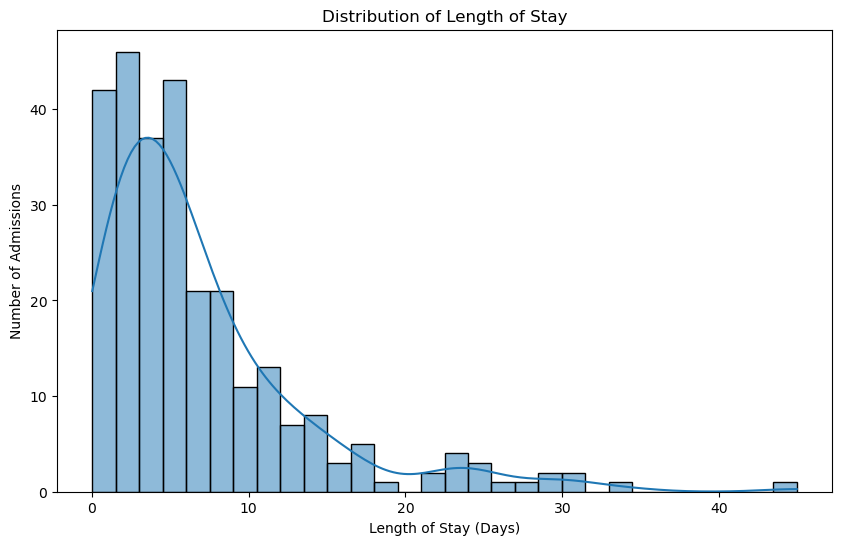

In [8]:
# Visualize distribution of length of stay
plt.figure(figsize=(10, 6))
sns.histplot(merged['length_of_stay'], bins=30, kde=True)
plt.title('Distribution of Length of Stay')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Number of Admissions')
plt.show()

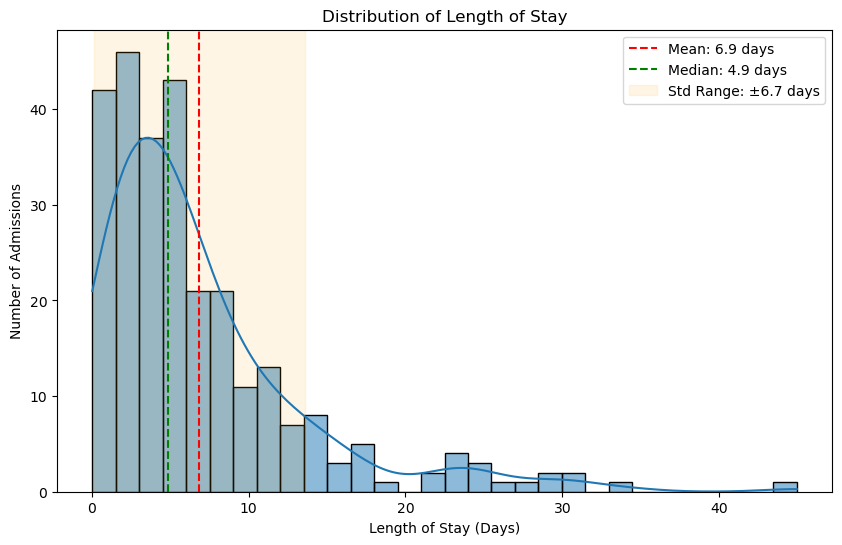

In [9]:
# Visualize distribution of length of stay
plt.figure(figsize=(10, 6))
sns.histplot(merged['length_of_stay'], bins=30, kde=True)

# Add vertical lines for mean and median
plt.axvline(merged['length_of_stay'].mean(), color='red', linestyle='--', label=f'Mean: {merged["length_of_stay"].mean():.1f} days')
plt.axvline(merged['length_of_stay'].median(), color='green', linestyle='--', label=f'Median: {merged["length_of_stay"].median():.1f} days')

# Add std annotation
plt.axvspan(
    merged['length_of_stay'].mean() - merged['length_of_stay'].std(),
    merged['length_of_stay'].mean() + merged['length_of_stay'].std(),
    alpha=0.1, color='orange', label=f'Std Range: ±{merged["length_of_stay"].std():.1f} days'
)

plt.title('Distribution of Length of Stay')
plt.xlabel('Length of Stay (Days)')
plt.ylabel('Number of Admissions')
plt.legend()
plt.show()

### Finding 1: Length of Stay Distribution
The distribution of length of stay is right-skewed, with most patients discharged within 5 days (median: 4.9 days). 
However, the mean of 6.9 days is pulled upward by a small number of long-stay outliers (up to 45 days). The high standard deviation(± 6.7 days) indicates significant variability in patient stays, making capacity planning challenging for hospital administrators.

In [10]:
# Distribution of admission types
print(merged['admission_type'].value_counts())

admission_type
EW EMER.                       104
OBSERVATION ADMIT               45
URGENT                          38
EU OBSERVATION                  30
SURGICAL SAME DAY ADMISSION     18
DIRECT EMER.                    15
ELECTIVE                        13
DIRECT OBSERVATION               7
AMBULATORY OBSERVATION           5
Name: count, dtype: int64


### Finding 2: Admission Type Distribution
Emergency walk-in admissions (EW EMER.) dominate with 104 out of 275 admissions (38%), confirming that this hospital operates primarily as an emergency care facility. 

Elective admissions represent only 13 cases, suggesting limited planned surgical capacity. 

Resource allocation should prioritise emergency department staffing and bed availability.

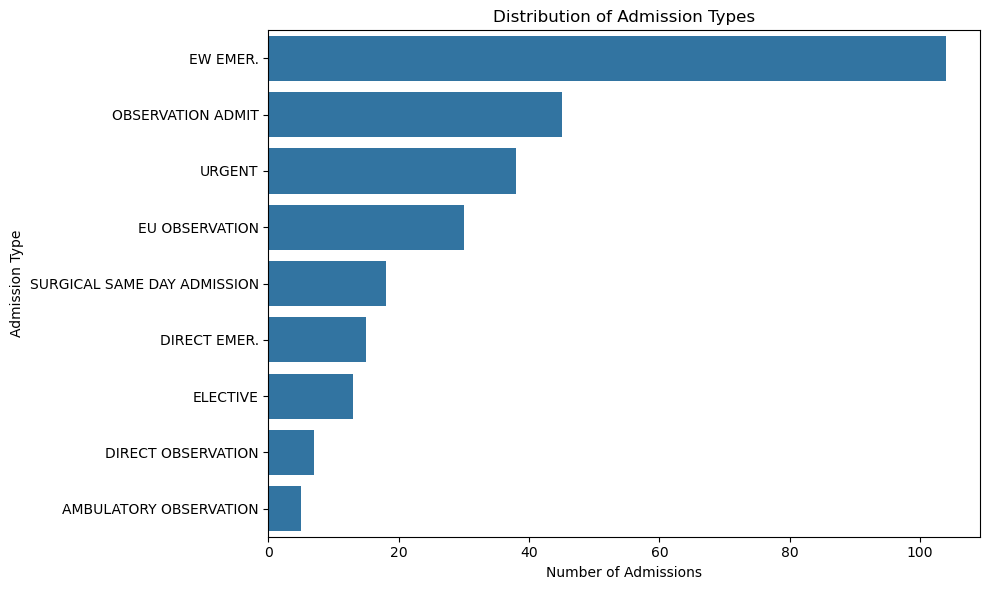

In [11]:
# Visualize admission types
plt.figure(figsize=(10, 6))
sns.countplot(data=merged, y='admission_type', order=merged['admission_type'].value_counts().index)
plt.title('Distribution of Admission Types')
plt.xlabel('Number of Admissions')
plt.ylabel('Admission Type')
plt.tight_layout()
plt.show()

### Finding 3: Length of Stay by Admission Type
Contrary to expectation, URGENT admissions have the longest average stay (9.9 days), surpassing EW EMER.(7.3 days) despite lower volume. This suggests urgent cases involve greater clinical complexity requiring extended treatment. Observation-basedadmissions (EU OBSERVATION, AMBULATORY OBSERVATION) have the shortest stays (under 
1 day), reflecting their monitoring-only nature. Hospitals should allocate more clinical resources per patient for urgent admissions, not just emergency volume.

In [12]:
# Average length of stay by admission type
los_by_type = merged.groupby('admission_type')['length_of_stay'].mean().sort_values(ascending=False)
print(los_by_type)

admission_type
URGENT                         9.850841
DIRECT EMER.                   9.389676
ELECTIVE                       8.190759
OBSERVATION ADMIT              8.151821
EW EMER.                       7.279320
SURGICAL SAME DAY ADMISSION    5.696258
DIRECT OBSERVATION             1.445139
AMBULATORY OBSERVATION         1.015278
EU OBSERVATION                 0.916921
Name: length_of_stay, dtype: float64


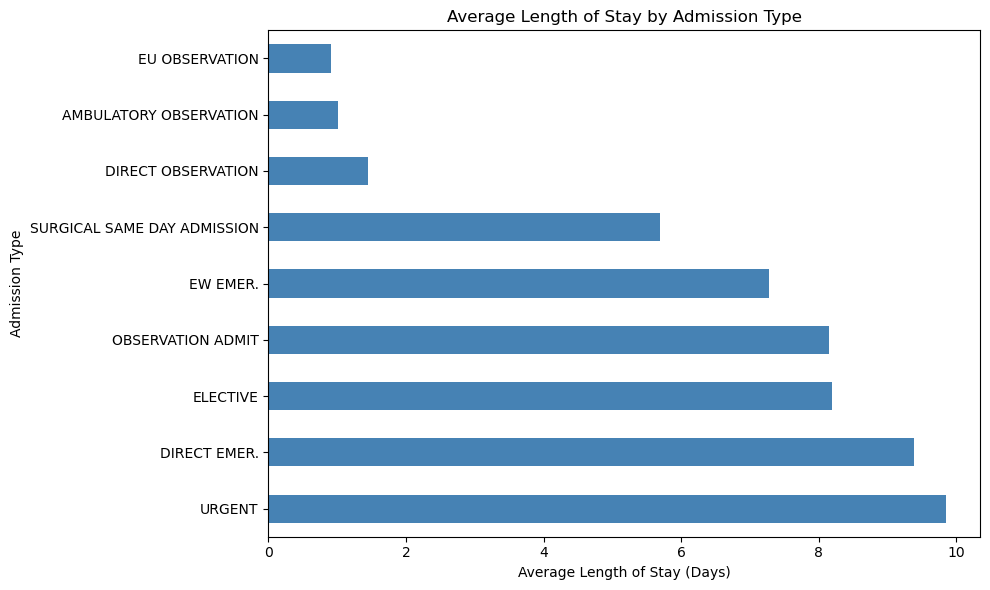

In [13]:
# Visualize average length of stay by admission type
plt.figure(figsize=(10, 6))
los_by_type.plot(kind='barh', color='steelblue')
plt.title('Average Length of Stay by Admission Type')
plt.xlabel('Average Length of Stay (Days)')
plt.ylabel('Admission Type')
plt.tight_layout()
plt.show()

In [14]:
# Hospital mortality analysis
mortality = merged['hospital_expire_flag'].value_counts()
print(mortality)

mortality_rate = merged['hospital_expire_flag'].mean() * 100
print(f"\nHospital Mortality Rate: {mortality_rate:.1f}%")

hospital_expire_flag
0    260
1     15
Name: count, dtype: int64

Hospital Mortality Rate: 5.5%


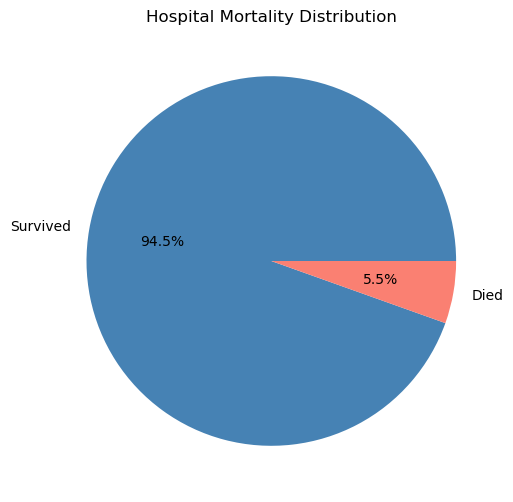

In [17]:
# Visualize mortality
plt.figure(figsize = (6, 6))
plt.pie(mortality, labels = ['Survived', 'Died'], autopct ='%1.1f%%', colors = ['steelblue', 'salmon'])
plt.title('Hospital Mortality Distribution')
plt.show()

### Finding 4: Hospital Mortality Rate
The in-hospital mortality rate is 5.5% (15 out of 275 admissions). This is slightly above the typical general hospital benchmark of 2-3%, but consistent with expected outcomes given the complexity of cases admitted, including emergency and urgent presentations. 260 patients(94.5%) were successfully discharged. Further analysis 
of mortality by admission type and diagnosis would help identify high-risk patient groups requiring targeted intervention.

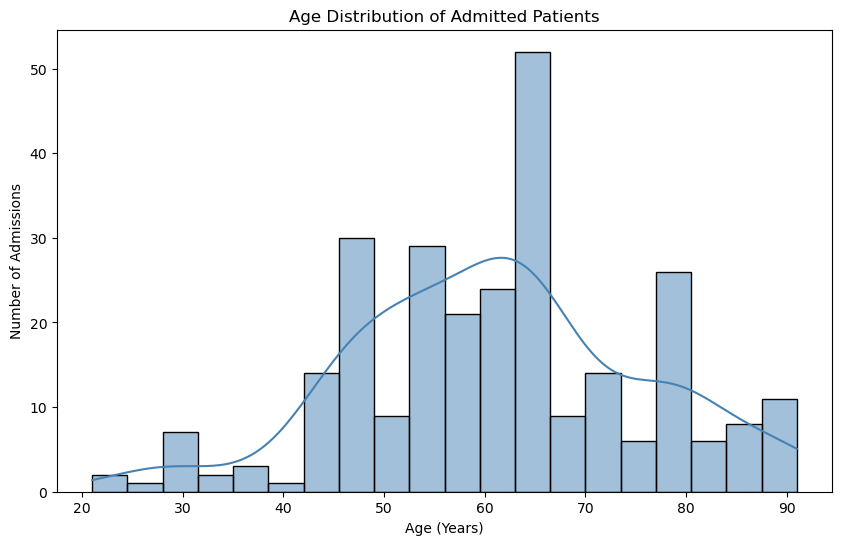

In [16]:
# Age distribution of patients
plt.figure(figsize=(10, 6))
sns.histplot(merged['anchor_age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution of Admitted Patients')
plt.xlabel('Age (Years)')
plt.ylabel('Number of Admissions')
plt.show()

### Finding 5: Age Distribution of Admitted Patients
The majority of admissions involve patients aged 50-75, with a peak in the 60-70 age group. Very few admissions involve patients under 30. This older adult demographic signals that the hospital should prioritise geriatric care capacity, chronic disease management programmes, and age-appropriate discharge planning. Staffing and infrastructure decisions should reflect the needs of an ageing patient population.

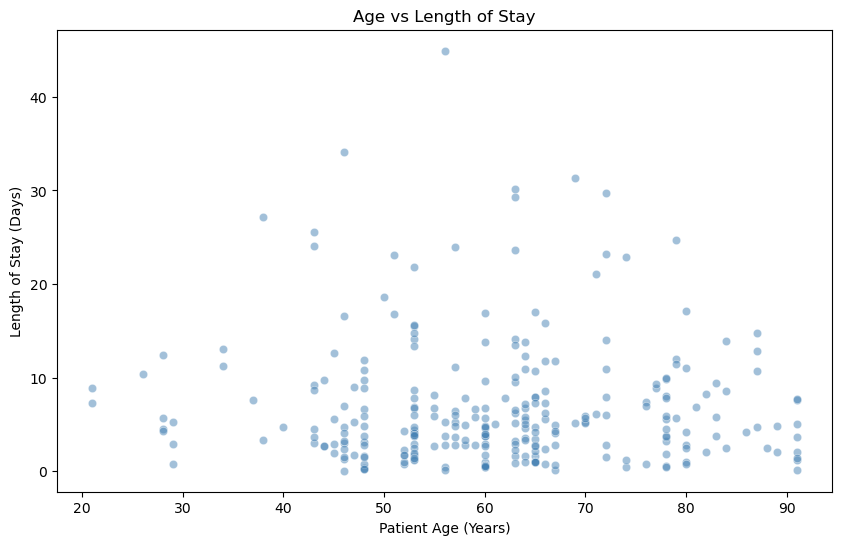

In [18]:
# Relationship between age and length of stay
plt.figure(figsize=(10, 6))
sns.scatterplot(data=merged, x='anchor_age', y='length_of_stay', alpha=0.5, color='steelblue')
plt.title('Age vs Length of Stay')
plt.xlabel('Patient Age (Years)')
plt.ylabel('Length of Stay (Days)')
plt.show()

### Finding 6: Age vs Length of Stay
Contrary to expectation, age alone does not strongly predict length of stay. Long stays are distributed across all age groups, from patients in their 40s to those in their 90s. This suggests that clinical complexity, diagnosis, and admission type are stronger predictors of length of stay than age. Hospitals avoid assumptions about discharge timelines based solely on patient age and instead focus on case-by-case clinical assessment.

## Summary of Key Findings

Emergency walk-in admissions dominate this hospital at 38% of all cases, confirming its emergency-focused nature. The typical patient stay is 4.9 days, though significant variability exists; some patients stay up to 45 days. Urgent admissions, despite lower volume, require the longest stays, averaging 9.9 days, signalling higher clinical complexity. 

In-hospital mortality sits at 5.5%, slightly above general hospital benchmarks. The patient population is predominantly older adults aged 50-75, with peak admissions in the 60-70 age group. Importantly, age alone does not predict length of stay; clinical complexity appears to be the stronger driver.

## Next Steps
1. Identify top diagnoses driving admissions using SQL
2. Build a Power BI dashboard from cleaned data  

In [19]:
# Export cleaned merged data for SQL analysis 

merged.to_csv('../data/cleaned/merged_admissions.csv', index=False)
print("Cleaned data exported successfully")


Cleaned data exported successfully
